# Raw Data — TopCV

In [7]:
import pandas as pd

# Hiển thị toàn bộ nội dung của mỗi cell
pd.set_option('display.max_colwidth', None)

# Hiển thị tất cả cột
pd.set_option('display.max_columns', None)

# Tăng chiều rộng hiển thị
pd.set_option('display.width', None)

# Hiển thị toàn bộ chiều rộng DataFrame
pd.set_option('display.expand_frame_repr', False)

In [14]:
df_raw = pd.read_csv("../../data/raw/00-topcv_raw.csv")

In [15]:
import pandas as pd
import numpy as np
import re

def thong_ke_missing_data(df):
    """
    Hàm thống kê dữ liệu thiếu dựa trên các điều kiện đặc thù:
    - Salary: Không có số = Missing
    - Skills: [] hoặc '[]' = Missing
    - Các cột khác: NaN hoặc chuỗi rỗng = Missing
    """
    df_temp = df.copy()
    
    # 1. Hàm kiểm tra salary (phải chứa ít nhất 1 chữ số)
    def check_salary_missing(val):
        if pd.isna(val): return True
        return not bool(re.search(r'\d', str(val)))
        
    # 2. Hàm kiểm tra mảng kỹ năng (list rỗng hoặc string '[]')
    def check_empty_array(val):
        if isinstance(val, list):
            return len(val) == 0
        if isinstance(val, str):
            return val.strip() in ['[]', "['']", '[""]', '']
        return pd.isna(val)

    # 3. Hàm kiểm tra các cột văn bản thông thường (NaN, rỗng, hoặc chỉ có khoảng trắng)
    def check_general_missing(val):
        if pd.isna(val): return True
        if isinstance(val, str) and val.strip() == '': return True
        return False

    # Duyệt qua từng cột trong DataFrame của bạn
    for col in df_temp.columns:
        if col == 'salary':
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_salary_missing(x) else x)
        elif col in ['required_skills', 'preferred_skills']:
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_empty_array(x) else x)
        else:
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_general_missing(x) else x)
            
    total_rows = len(df_temp)
    missing_counts = df_temp.isnull().sum()
    missing_percentages = (missing_counts / total_rows) * 100
    
    ket_qua = pd.DataFrame({
        'Số lượng thiếu': missing_counts,
        'Tỷ lệ (%)': missing_percentages.round(2)
    })
    
    ket_qua = ket_qua[ket_qua['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ (%)', ascending=False)
    
    return ket_qua

stats = thong_ke_missing_data(df_raw)
print(stats)

                  Số lượng thiếu  Tỷ lệ (%)
preferred_skills            2990      68.20
salary                      1879      42.86
required_skills             1787      40.76
industry                     283       6.46
experience                   218       4.97
employment_type              218       4.97
level                        218       4.97
job_description              218       4.97
education                    218       4.97
requirement                  218       4.97
job_title                    202       4.61
location                     202       4.61
company                       54       1.23


In [16]:
df_raw.shape

(4384, 16)

## Raw Data — ITViec

In [11]:
try:
    df_itviec_raw = pd.read_csv("../../data/raw/00-itviec_raw.csv")
    print(f"ITViec raw: {df_itviec_raw.shape}")
    stats_itviec = thong_ke_missing_data(df_itviec_raw)
    print(stats_itviec)
except FileNotFoundError:
    print("00-itviec_raw.csv not found — data chưa có chính thức, skip.")

ITViec raw: (751, 15)
                  Số lượng thiếu  Tỷ lệ (%)
experience                   751     100.00
specialization               751     100.00
education                    751     100.00
level                        751     100.00
employment_type              751     100.00
preferred_skills             751     100.00
salary                       566      75.37
industry                      14       1.86
location                       4       0.53


# Xử lý job title

In [1]:
import sys, pathlib, importlib.util

_main_dir = pathlib.Path().resolve() / "main"
for _alias, _file in [
    ("title_filter",     "03_title_filter.py"),
    ("title_normalizer", "03_title_normalizer.py"),
    ("salary_utils",     "03_salary_utils.py"),
]:
    _spec = importlib.util.spec_from_file_location(_alias, _main_dir / _file)
    _mod  = importlib.util.module_from_spec(_spec)
    sys.modules[_alias] = _mod
    _spec.loader.exec_module(_mod)

from title_filter import filter_by_standardized_title   # type: ignore[import]
from title_normalizer import normalize_titles            # type: ignore[import]
from salary_utils import add_salary_flags, get_valid_salary_mask  # type: ignore[import]

In [2]:
import pandas as pd

df_topcv = pd.read_csv("output/01-topcv_llm_standardized.csv")
print(f"TopCV LLM standardized: {len(df_topcv):,} rows")

TopCV LLM standardized: 2,588 rows


In [3]:
try:
    df_itviec = pd.read_csv("output/01-itviec_llm_standardized.csv")
    print(f"ITViec LLM standardized: {len(df_itviec):,} rows")
    ITVIEC_AVAILABLE = True
except FileNotFoundError:
    print("output/01-itviec_llm_standardized.csv not found — chạy 01_process_job_title.py --dataset itviec rồi 02_merge_job_title.py --dataset itviec trước.")
    df_itviec = None
    ITVIEC_AVAILABLE = False

ITViec LLM standardized: 749 rows


In [4]:
import pandas as pd

frames = [df_topcv.assign(source="topcv")]
if ITVIEC_AVAILABLE:
    frames.append(df_itviec.assign(source="itviec"))

df = pd.concat(frames, ignore_index=True)

src_counts = df["source"].value_counts().to_dict()
summary = ", ".join(f"{s}={c:,}" for s, c in src_counts.items())
print(f"Merged: {len(df):,} rows ({summary})")

Merged: 3,337 rows (topcv=2,588, itviec=749)


In [5]:
df.head(5)

,url,job_title,company,location,salary,experience,education,level,employment_type,industry,required_skills,preferred_skills,specialization,job_description,requirement,brand_recrawled,standardized_title,source
0,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,Hà Nội,8 - 20 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,[],[],"['2 năm kinh nghiệm', 'Đại Học trở lên', 'Soft...",- Tham gia các dự án phần mềm của Công ty. - X...,"- Tốt nghiệp Đại học, Cao đẳng, trung tâm đào ...",False,Backend Developer,topcv
1,https://www.topcv.vn/viec-lam/mobile-app-engin...,Mobile App Engineer ( IOS / Android ) – AI Gla...,CÔNG TY TNHH VEANIX,Hà Nội,Thoả thuận,Trên 5 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,IT - Phần mềm,"['Swift (ios) Hoặc Kotlin Java (android)', 'Lậ...","['Kiến Thức Về Ai Machine Learning', 'Kinh Ngh...","['Trên 5 năm kinh nghiệm', 'Đại Học trở lên', ...",Phát triển ứng dụng mobile (iOS / Android) cho...,Có kinh nghiệm phát triển mobile: iOS (Swift) ...,False,Mobile Developer,topcv
2,https://www.topcv.vn/viec-lam/backend-lead-eng...,Backend Lead Engineer,CÔNG TY TNHH LEVER SPHERE VIỆT NAM,Hà Nội,50 - 70 triệu,3 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,Luật,"['Thiết Kế Hệ Thống', 'System Design', 'Backen...","['Mysql/Postgresql', 'Php/Python/Java/Node.js']","['3 năm kinh nghiệm', 'Đại Học trở lên', 'Tuổi...",KEY OUTCOMES: NHỮNG KẾT QUẢ CỤ THỂ CẦN ĐẠT TRO...,NĂNG LỰC & KỸ NĂNG CẦN CÓ Expert Backend Stack...,False,Backend Developer,topcv
3,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên Nodejs Đi Làm Ngay Tại Hà Nội,Công ty cổ phần giải pháp MKT,Hà Nội,Tới 30 triệu,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,"['Git', 'SQLite', 'CI/CD', 'React', 'Node.js',...","['Native Addons (N-API)', 'Tauri', 'Publish ứn...","['1 năm kinh nghiệm', 'Đại Học trở lên', 'Tiến...",Phát triển ứng dụng desktop trên Windows sử dụ...,Tối thiểu 1 – 2 năm kinh nghiệm phát triển ứng...,False,Fullstack Developer,topcv
4,https://www.topcv.vn/viec-lam/ky-su-tu-van-man...,Kỹ Sư Tư Vấn Mạng/ Presale Network Engineer,Công ty Cổ phần Viễn thông - Tin học Bưu điện ...,Hà Nội,Tới 45 triệu,3 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,[],[],"['3 năm kinh nghiệm', 'Cao Đẳng trở lên', 'Ngh...","- Làm việc với khách hàng để thu thập yêu cầu,...",- Tốt nghiệp đại học chuyên ngành Công nghệ Th...,False,Network Engineer,topcv


In [6]:
title_counts = df['standardized_title'].value_counts()

single_titles = set(title_counts[title_counts == 1].index)
sample_desc = (
    df[df['standardized_title'].isin(single_titles)]
    .groupby('standardized_title')['job_description']
    .first()
)

job_title_stats = (
    title_counts
    .rename_axis('standardized_title')
    .reset_index(name='count')
)
job_title_stats['percentage'] = (job_title_stats['count'] / len(df) * 100).round(2)
job_title_stats['sample_description'] = job_title_stats['standardized_title'].map(sample_desc)

job_title_stats.to_csv("output/job_title_stats.csv", index=False, encoding="utf-8-sig")
print(job_title_stats.head())


    standardized_title  count  percentage sample_description
0    Backend Developer    344       10.31                NaN
1     Business Analyst    269        8.06                NaN
2          QA Engineer    231        6.92                NaN
3  Fullstack Developer    189        5.66                NaN
4           IT Support    167        5.00                NaN


In [7]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

title_counts = df['standardized_title'].value_counts()
title_percentages = (
    df['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

single_titles = set(job_title_stats[job_title_stats['count'] == 1].index)
sample_descriptions = (
    df[df['standardized_title'].isin(single_titles)]
    .groupby('standardized_title')['job_description']
    .first()
)

job_title_stats['sample_description'] = sample_descriptions
job_title_stats = (
    job_title_stats
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# Strip newlines so CSV stays single-line per row
job_title_stats['sample_description'] = (
    job_title_stats['sample_description']
    .str.replace(r'\r?\n', ' ', regex=True)
    .str.strip()
)

job_title_stats.to_csv(
    "output/job_title_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats.head())

    standardized_title  count  percentage sample_description
0    Backend Developer    344       10.31                NaN
1     Business Analyst    269        8.06                NaN
2          QA Engineer    231        6.92                NaN
3  Fullstack Developer    189        5.66                NaN
4           IT Support    167        5.00                NaN


In [8]:
samples = df[
    df['standardized_title']
    .str.strip()
    .str.lower()
    .eq('customer success')
][[
    'source',
    'job_title',
    'standardized_title',
    'job_description'
]]

samples = samples.sample(
    n=min(5, len(samples)),
    random_state=42
)

for i, row in samples.iterrows():
    print("=" * 100)
    print(f"SOURCE          : {row['source']}")
    print(f"JOB TITLE       : {row['job_title']}")
    print(f"STANDARDIZED    : {row['standardized_title']}")
    print(f"\nJOB DESCRIPTION :\n{str(row['job_description'])[:3000]}")
    print()

In [9]:
df_filtered, df_dropped = filter_by_standardized_title(df)

print(f"Original rows : {len(df):,}")
print(f"Filtered rows : {len(df_filtered):,}")
print(f"Dropped rows  : {len(df_dropped):,}")
print()
print("Breakdown by source after filter:")
print(df_filtered["source"].value_counts().to_string())

Original rows : 3,337
Filtered rows : 3,181
Dropped rows  : 156

Breakdown by source after filter:
source
topcv     2440
itviec     741


In [10]:
df_filtered = normalize_titles(df_filtered)
print("Titles normalized.")

Titles normalized.


In [11]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

title_counts = df_filtered['standardized_title'].value_counts()
title_percentages = (
    df_filtered['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats_filtered = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

single_titles = set(job_title_stats_filtered[job_title_stats_filtered['count'] == 1].index)
sample_descriptions = (
    df_filtered[df_filtered['standardized_title'].isin(single_titles)]
    .groupby('standardized_title')['job_description']
    .first()
)

job_title_stats_filtered['sample_description'] = sample_descriptions
job_title_stats_filtered = (
    job_title_stats_filtered
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# Strip newlines so CSV stays single-line per row
job_title_stats_filtered['sample_description'] = (
    job_title_stats_filtered['sample_description']
    .str.replace(r'\r?\n', ' ', regex=True)
    .str.strip()
)

job_title_stats_filtered.to_csv(
    "output/job_title_stats_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats_filtered.head())

    standardized_title  count  percentage sample_description
0    Backend Developer    344       10.81                NaN
1     Business Analyst    269        8.46                NaN
2          QA Engineer    231        7.26                NaN
3  Fullstack Developer    189        5.94                NaN
4           IT Support    168        5.28                NaN


In [12]:
df_filtered.shape

(3181, 18)

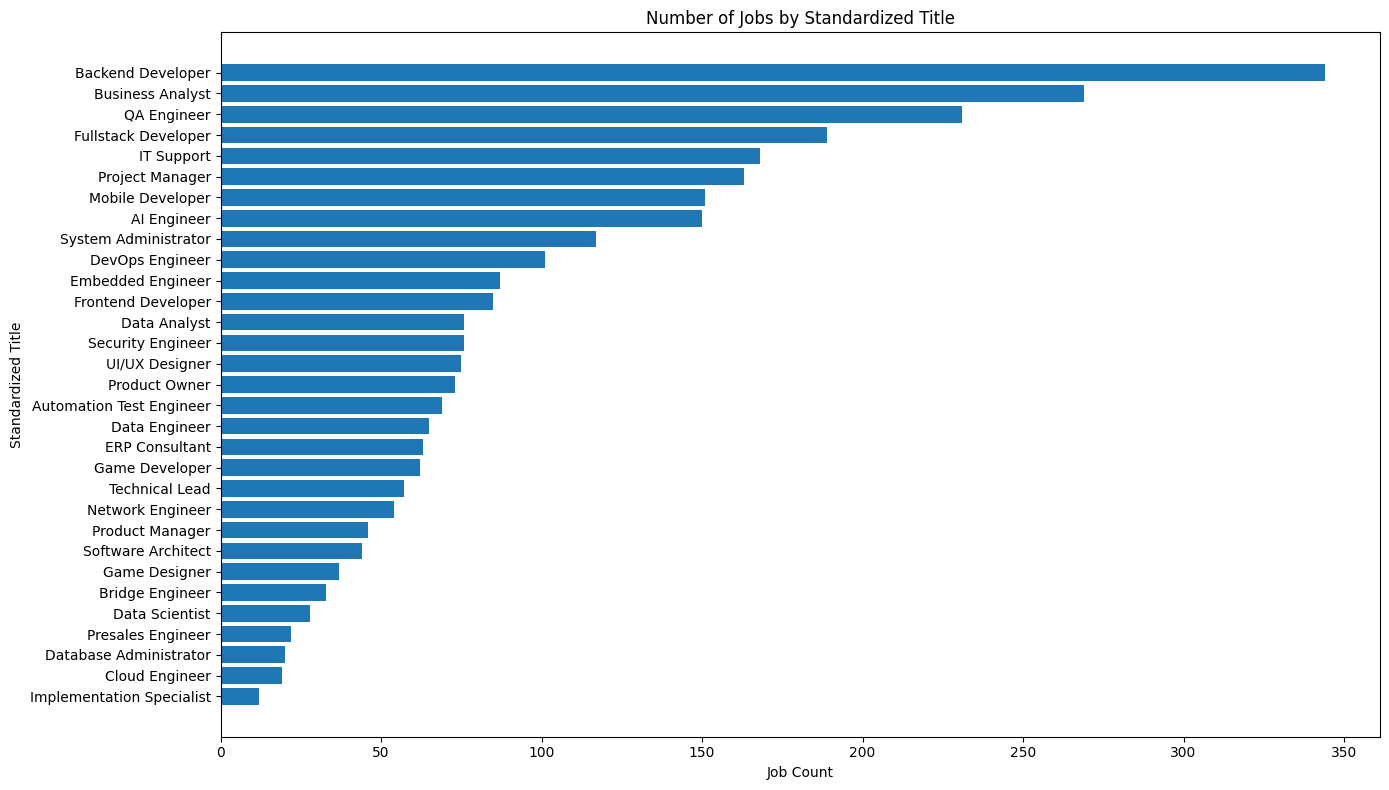

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# COUNT JOBS BY TITLE
# =========================

result = (
    df_filtered.groupby("standardized_title")
    .size()
    .reset_index(name="count")
)

# chỉ lấy title có >= 10 dòng
plot_df = result[
    result["count"] >= 10
].sort_values(
    "count",
    ascending=False
)

# =========================
# VISUALIZE
# =========================

plt.figure(figsize=(14, 8))

plt.barh(
    plot_df["standardized_title"],
    plot_df["count"]
)

plt.xlabel("Job Count")
plt.ylabel("Standardized Title")
plt.title("Number of Jobs by Standardized Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
df_filtered.head(1)

,url,job_title,company,location,salary,experience,education,level,employment_type,industry,required_skills,preferred_skills,specialization,job_description,requirement,brand_recrawled,standardized_title,source
0,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,Hà Nội,8 - 20 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,[],[],"['2 năm kinh nghiệm', 'Đại Học trở lên', 'Soft...",- Tham gia các dự án phần mềm của Công ty. - X...,"- Tốt nghiệp Đại học, Cao đẳng, trung tâm đào ...",False,Backend Developer,topcv


In [15]:
from pathlib import Path

cols_to_drop = ["is_null_salary", "is_thoa_thuan", "is_missing_salary", "brand_recrawled"]
df_out = df_filtered.drop(columns=cols_to_drop, errors="ignore")

out_path = Path("../../data/interim/01-standardized_title.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

df_out.to_csv(out_path, index=False, encoding="utf-8")
print(f"Saved to: {out_path.resolve()}")
print(f"Shape: {df_out.shape} | Cols: {df_out.columns.tolist()}")

Saved to: C:\Users\tncn2\Documents\HK2-2026_2027\DS108\DS108\data\interim\01-standardized_title.csv
Shape: (3181, 17) | Cols: ['url', 'job_title', 'company', 'location', 'salary', 'experience', 'education', 'level', 'employment_type', 'industry', 'required_skills', 'preferred_skills', 'specialization', 'job_description', 'requirement', 'standardized_title', 'source']
